# Saliency Analysis for Demo

- This is a scratch script for creating visuals and studying the saliency maps produced for this experiment.

In [1]:
import numpy as np

import pandas as pd
import seaborn as sns

import plotly.express as px
import matplotlib.pyplot as plt

In [2]:
def flatten_embeddings(embeddings):

    output_embeddings = []

    for k in range(embeddings.shape[0]):
        for t in range(embeddings.shape[1]):
            output_embeddings.append(embeddings[k, t, :])

    return np.array(output_embeddings)

In [3]:
hopfield_saliency = np.load("/Users/johannesbauer/Documents/Coding/neuro_comp_project/results/saliency_maps/hopfield_only/hopfield_saliency_maps.npy")
tf_saliency = np.load("/Users/johannesbauer/Documents/Coding/neuro_comp_project/results/saliency_maps/tf/transformer_saliency_maps.npy")
tf_hopfield_saliency = np.load("/Users/johannesbauer/Documents/Coding/neuro_comp_project/results/saliency_maps/tf_hopfield/tf_hopfield_saliency_maps.npy")


In [4]:
hopfield_saliency.shape

(73, 100, 55)

In [5]:
flattened_embeddings_hopfield = flatten_embeddings(hopfield_saliency)
flatteened_embeddings_tf = flatten_embeddings(tf_saliency)
flattened_embeddings_tf_hopfield = flatten_embeddings(tf_hopfield_saliency)

In [6]:
lst_of_flatened_embeddings = [flattened_embeddings_hopfield,
                              flatteened_embeddings_tf,
                              flattened_embeddings_tf_hopfield]

labels_lst = ["Hopfield Only",
              "Transformer",
              "Tranformer + Hopfield"]

In [ ]:
lst_of_cols = []
lst_of_idxs = []

mean_lst = []
stdev_lst = []

for lb_1, emb_1 in zip(labels_lst, lst_of_flatened_embeddings):
    for lb_2, emb_2 in zip(labels_lst, lst_of_flatened_embeddings):
        lst_of_cols.append(lb_1)
        lst_of_idxs.append(lb_2)
        mean_lst.append(np.mean(np.sum(np.abs(emb_1 - emb_2), axis=-1)))
        stdev_lst.append(np.std(np.sum(np.abs(emb_1 - emb_2), axis=-1)))

In [20]:
from scipy import stats

In [21]:
flattened_embeddings_hopfield.shape

(7300, 55)

In [ ]:
lst_of_flatened_embeddings = [flattened_embeddings_hopfield,
                              flatteened_embeddings_tf,
                              flattened_embeddings_tf_hopfield]

In [38]:
out = np.sum(np.abs(flatteened_embeddings_tf - flattened_embeddings_tf_hopfield), axis=-1)

In [39]:
t_stat, p_value = stats.ttest_1samp(out, popmean=0)

In [40]:
p_value

0.0

In [8]:
new_df = pd.pivot_table(data=pd.DataFrame({'col': lst_of_cols, 'idx': lst_of_idxs, 'mean': mean_lst}), values=['mean'], index='col', columns='idx')

Text(0.5, 1.0, 'Distribution of Differences Between Attribution Maps')

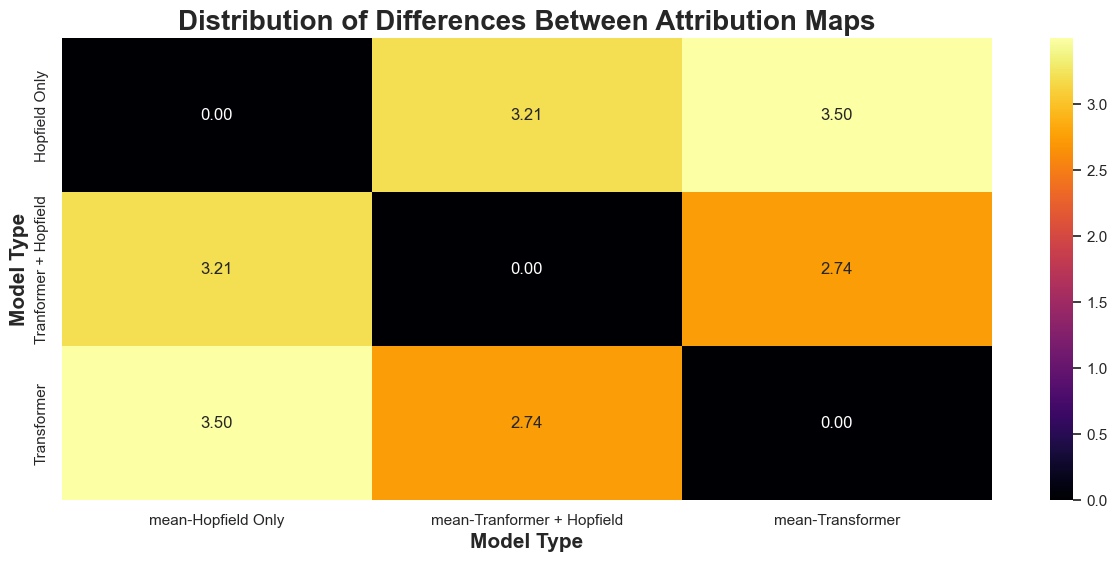

In [9]:
sns.set_theme()
fig, ax = plt.subplots(figsize=(15,6))

sns.heatmap(new_df, ax = ax, annot = True, fmt=".2f", cmap="inferno")
ax.set_xlabel("Model Type", weight = "bold", size = 15)
ax.set_ylabel("Model Type", weight = "bold", size = 15)
ax.set_title("Distribution of Differences Between Attribution Maps", weight = "bold", size = 20)

In [10]:
out = np.sum(np.abs(flattened_embeddings_hopfield - flatteened_embeddings_tf), axis=-1)

In [11]:
np.mean(out)

3.4967906

In [12]:
px.box(x = out)

In [13]:
100*55

5500

In [14]:
average_mean_diff_lst = []
for idx in range(hopfield_saliency.shape[0]):
    sal_hopfield = hopfield_saliency[idx]
    sal_tf = tf_saliency[idx]
    sal_hopfield_tf = tf_hopfield_saliency[idx]

    diff_1 = np.sum(np.abs(sal_hopfield - sal_tf))
    diff_2 = np.sum(np.abs(sal_hopfield - sal_hopfield_tf))
    diff_3 = np.sum(np.abs(sal_tf - sal_hopfield_tf))

    average_mean_diff_lst.append(np.mean([diff_1, diff_2, diff_3]))


In [15]:
np.argmax(average_mean_diff_lst)

8

In [16]:
eps = 5
np.argwhere((average_mean_diff_lst < np.mean(average_mean_diff_lst) + eps) & (average_mean_diff_lst > np.mean(average_mean_diff_lst) - eps))

array([[ 9],
       [23],
       [65]])

In [17]:
average_mean_diff_lst[8]

581.36664

In [18]:
np.min(average_mean_diff_lst)

108.64868

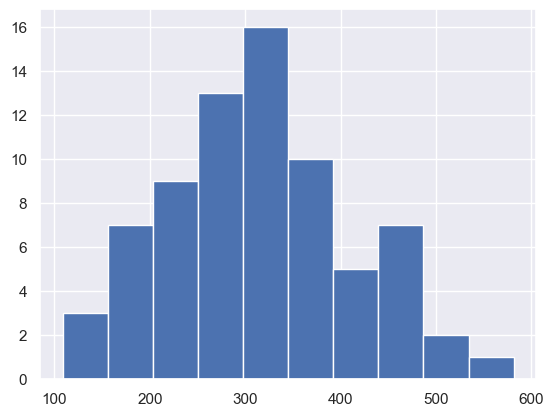

In [19]:
plt.hist(average_mean_diff_lst);

In [ ]:
hopfield_saliency.shape

In [ ]:
np.abs(emb_1 - emb_2).shape

In [ ]:
import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = [20, 10]  # set globally

In [ ]:
idx = 8
plt.figure(figsize=(20, 5))
fig, ax = plt.subplots(figsize = (20, 5))
fig.set_figwidth(20)
ax.imshow(hopfield_saliency[idx].T, cmap = "jet",  aspect='auto')
ax.set_title("Saliency Map for Hopfield Only (High)", weight = "bold", size = 18)
plt.xlabel("Time (Binned Intervals)", weight = "bold", size = 15)
plt.ylabel("Sensor Dimension", weight = "bold", size = 15)

In [ ]:
fig, ax = plt.subplots(figsize = (20, 5))
ax.imshow(tf_hopfield_saliency[idx].T, cmap = "jet", aspect='auto')
ax.set_title("Saliency Map for Hopfield + Transformer (High)", weight = "bold", size = 15)

plt.xlabel("Time (Binned Intervals)", weight = "bold", size = 15)
plt.ylabel("Sensor Dimension", weight = "bold", size = 15)

In [ ]:
fig, ax = plt.subplots(figsize = (20, 5))
ax.imshow(tf_saliency[idx].T, cmap = "jet", aspect='auto')
ax.set_title("Saliency Map for Transformer (High)", weight = "bold", size = 15)

plt.xlabel("Time (Binned Intervals)", weight = "bold", size = 15)
plt.ylabel("Sensor Dimension", weight = "bold", size = 15)